In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pickle
from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.PRiSM_functions import partialResponses, normalise, prPlots
from prism.load_models import load_mlp
from prism.pr_save_test import save_partial_responses

2024-08-05 14:15:30.414 | INFO     | prism.config:<module>:11 - PROJ_ROOT path is: C:\Users\Henry Pigot\Documents\MEGAsync\2024 post doc\explainable survival prediction model\prism_github


In [2]:
%reload_ext autoreload

## Load and preprocess data

In [3]:
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

data_train_test = pd.concat([data_train,data_test]) # used for axis annotation in some plotting functions

# drop id column
data_train.drop('trr_id_code',axis=1,inplace=True)
data_test.drop('trr_id_code',axis=1,inplace=True)
data_val.drop('trr_id_code',axis=1,inplace=True)

target_col = 'oneyearmort'

x_train0 = data_train.drop(target_col,axis=1)
y_train = data_train[target_col]

x_test0 = data_test.drop(target_col,axis=1)
y_test = data_test[target_col]

x_val0 = data_val.drop(target_col,axis=1)
y_val = data_val[target_col]

[x_train,x_test] = normalise(x_train0,x_test0)
x_val = normalise(x_val0)

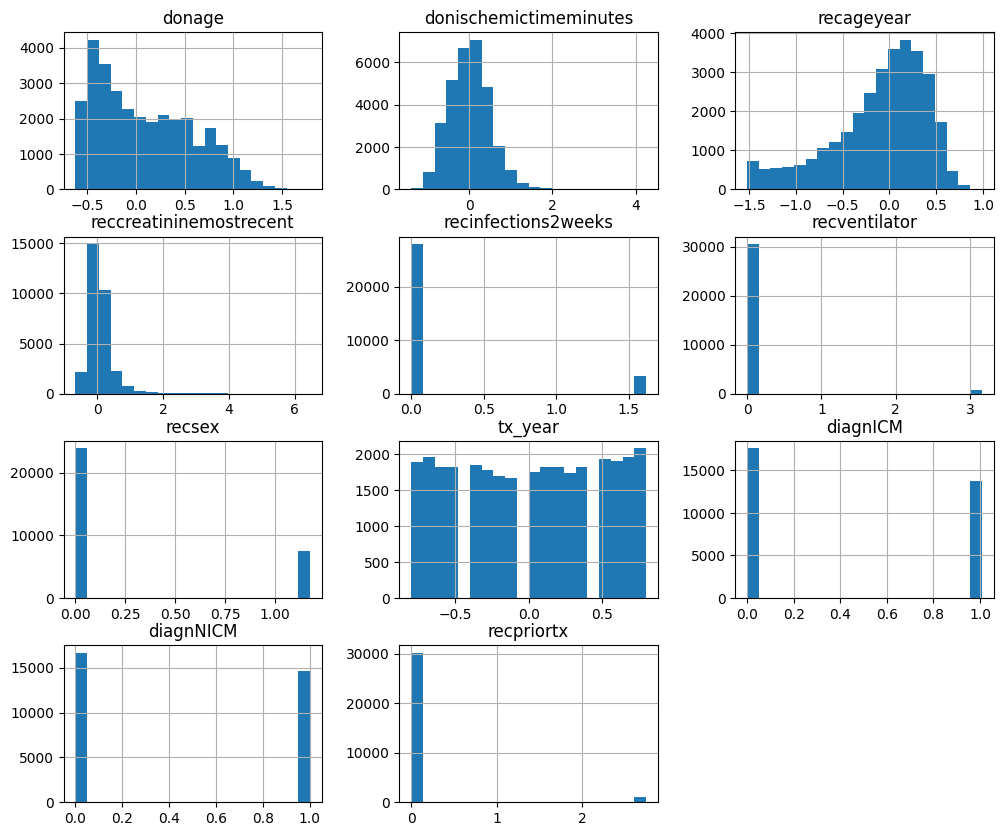

In [4]:
x_train.hist(bins=20,figsize=(12,10));

## Load MLP

In [5]:
filename_mlp = 'mlp_model_20240705_135534'
try:
    model, params, metrics = load_mlp(filename_mlp, MODELS_DIR)
    print("Model loaded successfully")
    print("Derived Model Structure:")
    print(f"Input dimension: {params['input_dim']}")
    print(f"Hidden units: {params['hidden_units']}")
    print(f"Output dimension: {params['output_dim']}")
    print("\nModel Parameters:")
    print(params)
    print("\nModel Metrics:")
    print(metrics)
except Exception as e:
    print(f"Error loading model: {e}")
    raise

# Extract method and device from params, with defaults
method = params.get('method', 'dirac')
device = params.get('device', 'cpu')

Model loaded successfully
Derived Model Structure:
Input dimension: 11
Hidden units: 10
Output dimension: 1

Model Parameters:
{'n_hidden': 10, 'weight_decay': 1e-05, 'lr': 0.001, 'patience': 50, 'tolerance': 0.0001, 'batch_size': 1024, 'device': 'cpu', 'seed': 257, 'input_dim': 11, 'hidden_units': 10, 'output_dim': 1}

Model Metrics:
{'prevalence': 0.123, 'sensitivity': 0.241, 'specificity': 0.864, 'accuracy': 0.797, 'ppv': 0.175, 'auc score': 0.601, 'auc lower ci': '0.577', 'auc upper ci': '0.626'}


## Calculate and save partial responses (existing benchmark implementation)

In [25]:
pr_train_benchmark, pr_test_benchmark, bivariate_inputs = save_partial_responses(x_train, x_test, model, method=method, device=device, filename="partial_responses_data.pkl")

print(f"Partial responses calculated using method '{method}' on device '{device}' and saved.")

Univariate Responses:
Column 0:
Column 1:
Column 2:
Column 3:
Column 4:
Column 5:
Column 6:
Column 7:
Column 8:
Column 9:
Column 10:
Bivariate Responses:
Columns 0 & 1:
Columns 0 & 2:
Columns 0 & 3:
Columns 0 & 4:
Columns 0 & 5:
Columns 0 & 6:
Columns 0 & 7:
Columns 0 & 8:
Columns 0 & 9:
Columns 0 & 10:
Columns 1 & 2:
Columns 1 & 3:
Columns 1 & 4:
Columns 1 & 5:
Columns 1 & 6:
Columns 1 & 7:
Columns 1 & 8:
Columns 1 & 9:
Columns 1 & 10:
Columns 2 & 3:
Columns 2 & 4:
Columns 2 & 5:
Columns 2 & 6:
Columns 2 & 7:
Columns 2 & 8:
Columns 2 & 9:
Columns 2 & 10:
Columns 3 & 4:
Columns 3 & 5:
Columns 3 & 6:
Columns 3 & 7:
Columns 3 & 8:
Columns 3 & 9:
Columns 3 & 10:
Columns 4 & 5:
Columns 4 & 6:
Columns 4 & 7:
Columns 4 & 8:
Columns 4 & 9:
Columns 4 & 10:
Columns 5 & 6:
Columns 5 & 7:
Columns 5 & 8:
Columns 5 & 9:
Columns 5 & 10:
Columns 6 & 7:
Columns 6 & 8:
Columns 6 & 9:
Columns 6 & 10:
Columns 7 & 8:
Columns 7 & 9:
Columns 7 & 10:
Columns 8 & 9:
Columns 8 & 10:
Columns 9 & 10:
Residual
Da

In [34]:
pr_train_benchmark.shape

(31315, 66)

In [44]:
x_train.columns[2]

'recageyear'

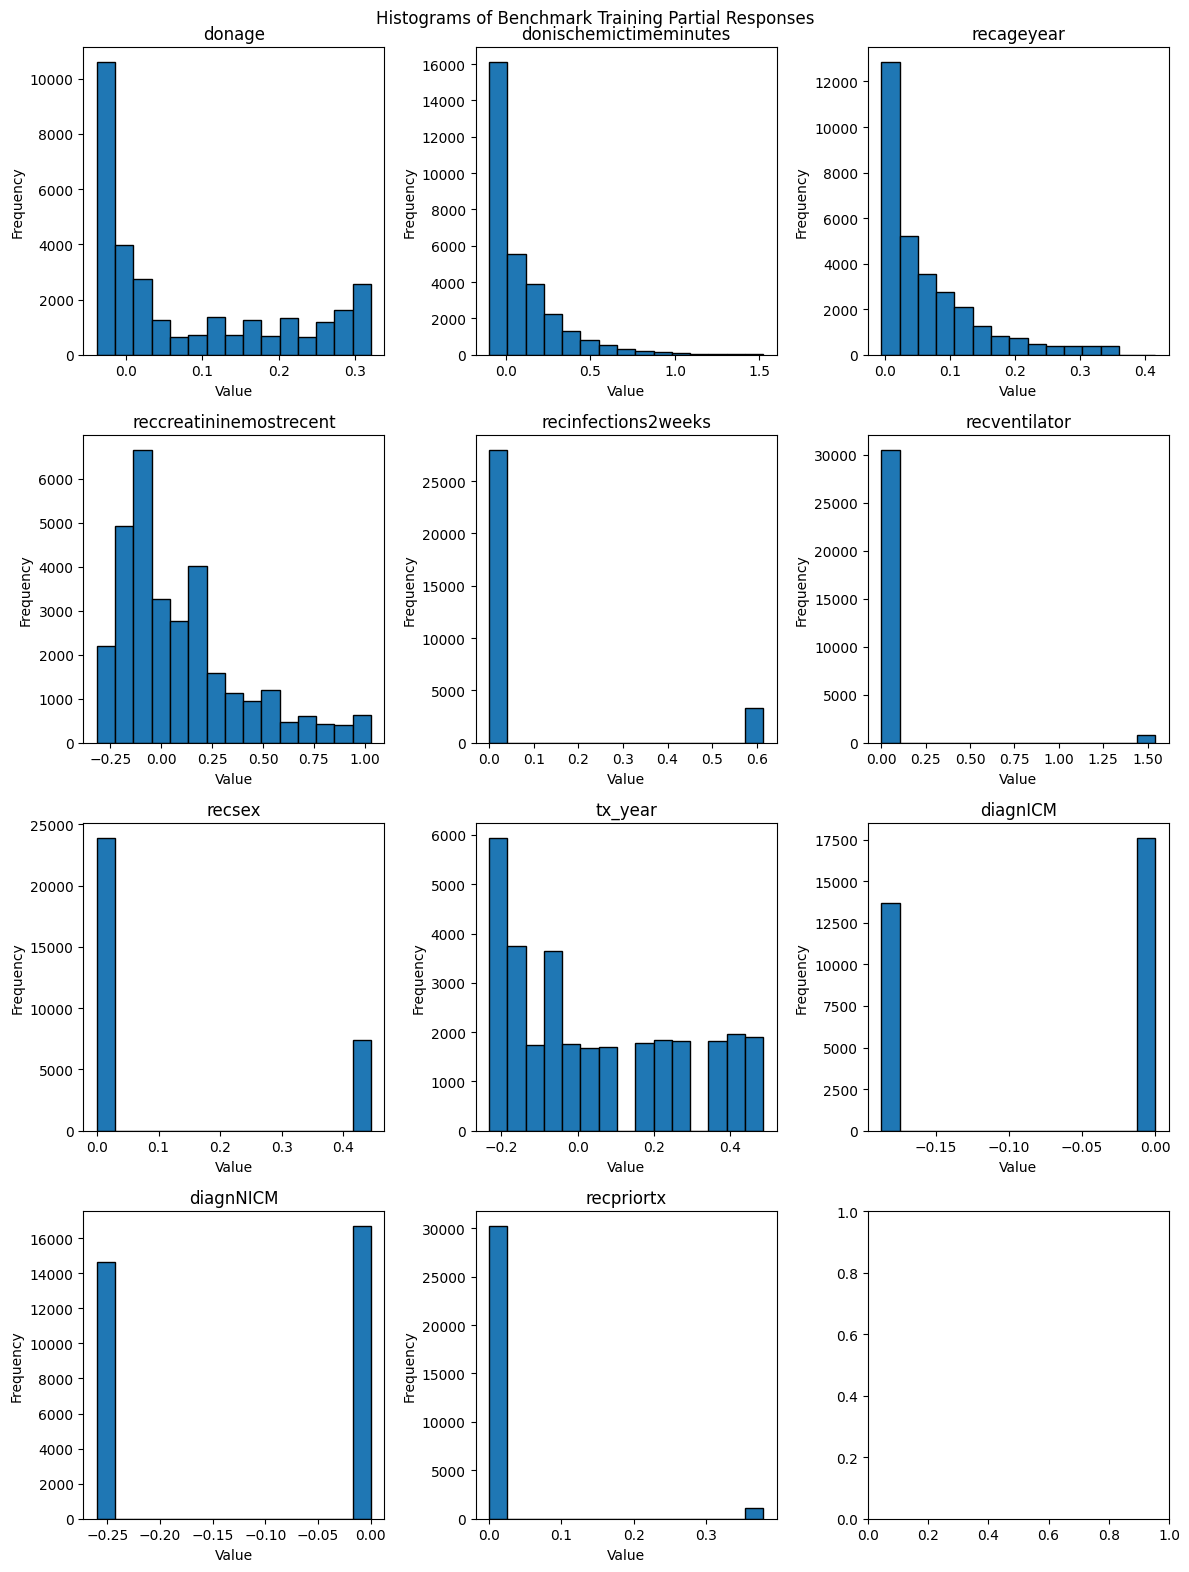

In [45]:
import matplotlib.pyplot as plt

# Univariate responses only
n = pr_train_benchmark.shape[0]
m = 11 

# Calculate number of rows needed for the subplots
num_subplot_cols = 3
num_subplot_rows = (m + num_subplot_cols - 1) // num_subplot_cols

# Create a figure with subplots arranged in 3 columns
fig, axes = plt.subplots(num_subplot_rows, num_subplot_cols, figsize=(12, 4 * num_subplot_rows))
fig.suptitle(f'Histograms of Benchmark Training Partial Responses')

# Plot histogram for each column
for i in range(m):
    row = i // num_subplot_cols
    col = i % num_subplot_cols
    ax = axes[row, col]
    ax.hist(pr_train_benchmark[:, i], bins=15, edgecolor='black')
    ax.set_title(x_train.columns[i])
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

## Plot partial responses

In [26]:
pr_test_benchmark.shape, x_test.shape

((6120, 66), (6120, 11))

In [27]:
betas_univariate = np.zeros([pr_train_benchmark.shape[1],1])
betas_univariate[:x_train.shape[1],0] = 1

0 - univ


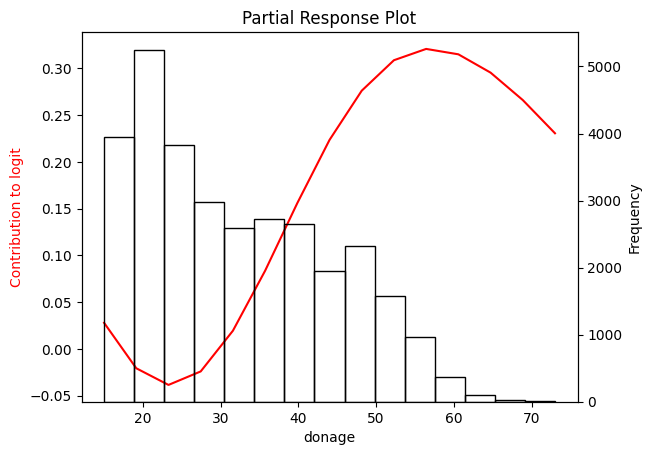

1 - univ


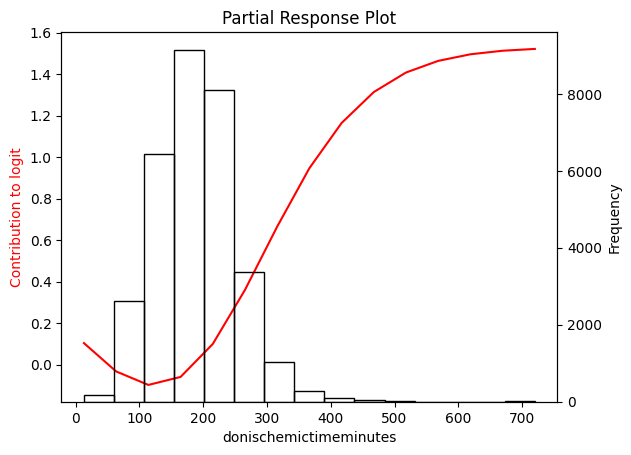

2 - univ


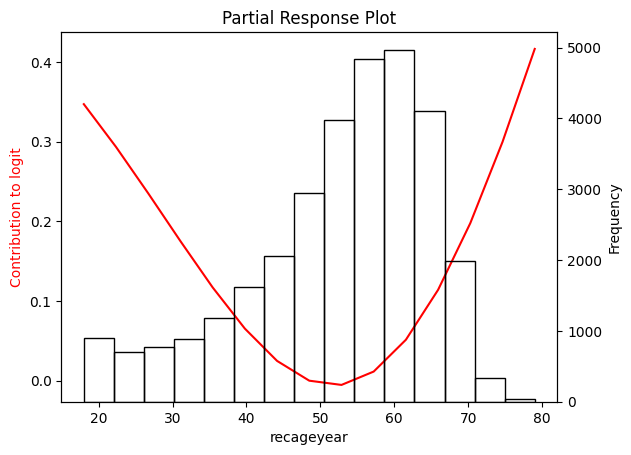

3 - univ


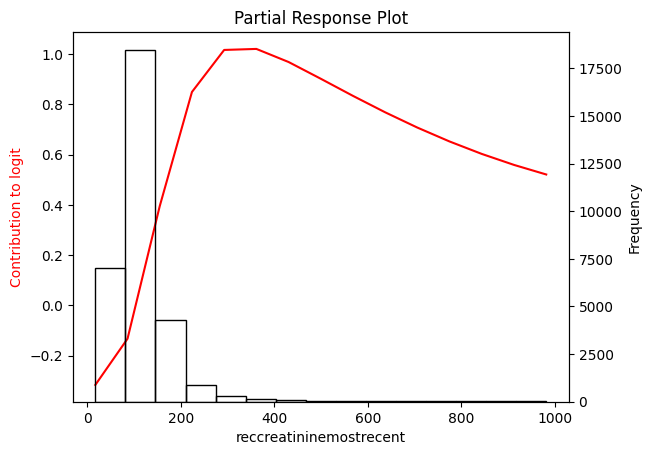

4 - univ


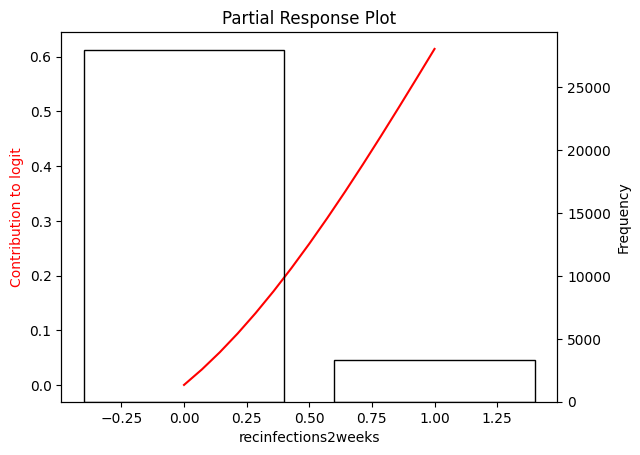

5 - univ


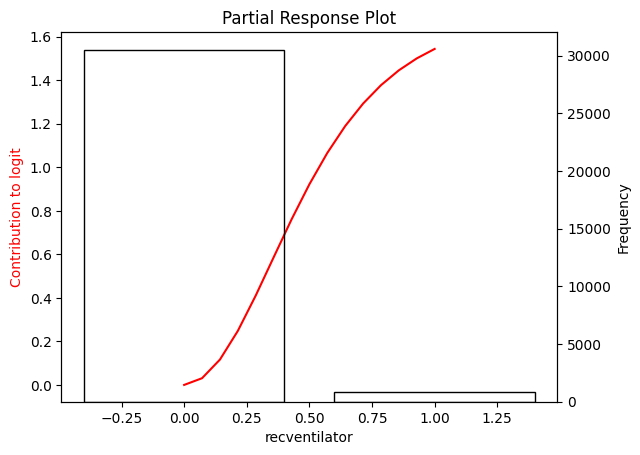

6 - univ


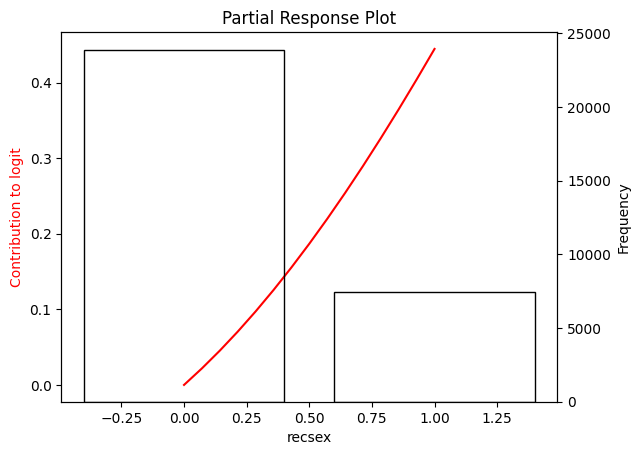

7 - univ


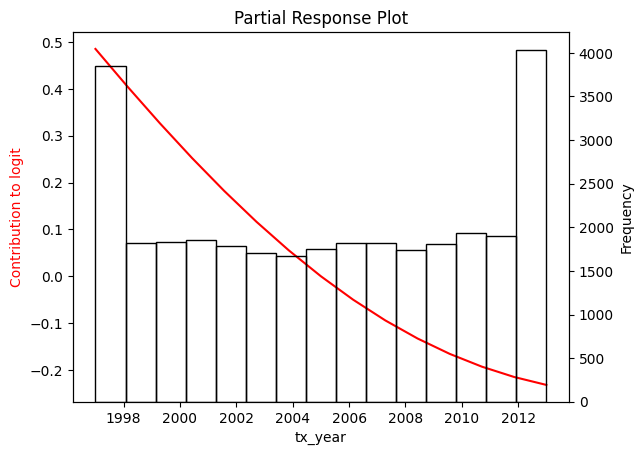

8 - univ


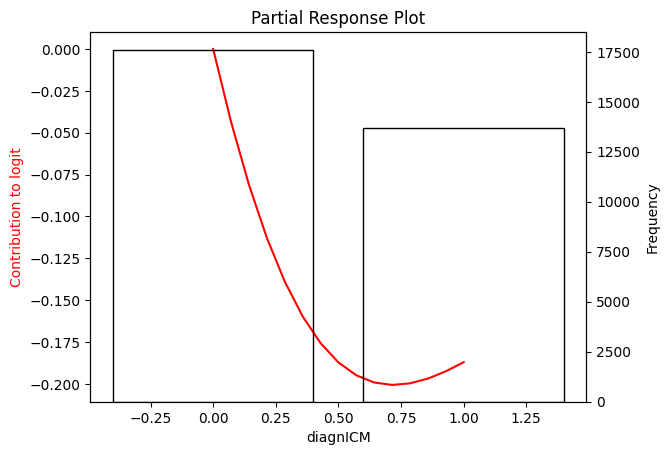

9 - univ


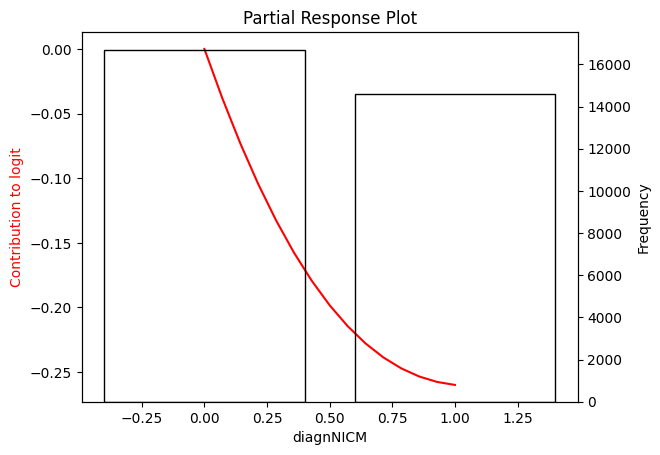

10 - univ


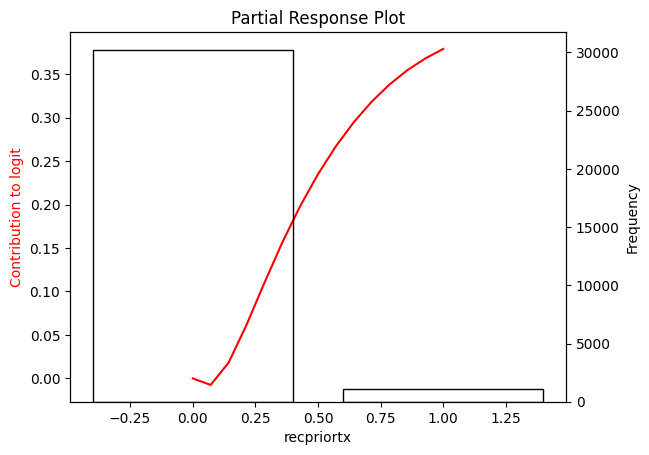

In [28]:
prPlots(betas_univariate, 0, x_train0, x_train, data_train_test, model, bivariate_inputs, n_steps = 15, sd_scale=2, method=method, device=device)

## Test the saved partial responses to verify test function

In [24]:
test_result = test_refactored_partial_responses(partialResponses, filename="partial_responses_data.pkl")

if test_result:
    print("Test passed.")
else:
    print("Test failed.")

Univariate Responses:
Column 0:
Column 1:
Column 2:
Column 3:
Column 4:
Column 5:
Column 6:
Column 7:
Column 8:
Column 9:
Column 10:
Bivariate Responses:
Columns 0 & 1:
Columns 0 & 2:
Columns 0 & 3:
Columns 0 & 4:
Columns 0 & 5:
Columns 0 & 6:
Columns 0 & 7:
Columns 0 & 8:
Columns 0 & 9:
Columns 0 & 10:
Columns 1 & 2:
Columns 1 & 3:
Columns 1 & 4:
Columns 1 & 5:
Columns 1 & 6:
Columns 1 & 7:
Columns 1 & 8:
Columns 1 & 9:
Columns 1 & 10:
Columns 2 & 3:
Columns 2 & 4:
Columns 2 & 5:
Columns 2 & 6:
Columns 2 & 7:
Columns 2 & 8:
Columns 2 & 9:
Columns 2 & 10:
Columns 3 & 4:
Columns 3 & 5:
Columns 3 & 6:
Columns 3 & 7:
Columns 3 & 8:
Columns 3 & 9:
Columns 3 & 10:
Columns 4 & 5:
Columns 4 & 6:
Columns 4 & 7:
Columns 4 & 8:
Columns 4 & 9:
Columns 4 & 10:
Columns 5 & 6:
Columns 5 & 7:
Columns 5 & 8:
Columns 5 & 9:
Columns 5 & 10:
Columns 6 & 7:
Columns 6 & 8:
Columns 6 & 9:
Columns 6 & 10:
Columns 7 & 8:
Columns 7 & 9:
Columns 7 & 10:
Columns 8 & 9:
Columns 8 & 10:
Columns 9 & 10:
Residual
Re